# 01 – Data Preparation & Leakage Control (M1)
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Dataset:** DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
**Task:** Regression – predict **`Days for shipping (real)`** (how many days an order takes to ship) **at the moment the order is placed**.
**Owner:** M1 (Lead / Data pipeline)

### What this notebook does
1. Loads the raw data correctly (Latin-1 encoding).
2. **Proves** with data which columns leak the answer, then removes them.
3. Removes cancelled / suspected-fraud orders (never shipped).
4. Drops personal, empty, constant and duplicate columns – every drop is logged with a reason.
5. Creates **one shared train/test split, grouped by Order Id**, used by the whole team.
6. Sets two baselines that every later model must beat.

### Files it saves
| File | Used by |
|---|---|
| `data/processed/train_reg.csv`, `test_reg.csv` | M2, M3, M4 |
| `data/processed/split_meta_reg.json` | everyone, backend |
| `reports/drop_log_m1_reg.csv` | report + viva |

**Run order for the team:** `01 (M1) → 02 (M2) → 03 (M3) → 04 (M4)`.
Put the raw file at `data/raw/DataCoSupplyChainDataset.csv` and run this notebook from the `notebooks/` folder.

## Step 0 – Setup
All paths and constants are defined once, so every run gives the same result (`SEED = 42`) and nobody hard-codes paths.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "DataCoSupplyChainDataset.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Days for shipping (real)"          # what we predict
SCHED = "Days for shipment (scheduled)"      # dropped later: redundant with Shipping Mode
LATE = "Late_delivery_risk"                  # dropped later: calculated from the target (leakage)
GROUP = "Order Id"                           # grouping key for the split
SEED = 42
DATE_FMT = "%m/%d/%Y %H:%M"
print("Project root:", ROOT)

Project root: /Users/gayandesilva/Documents/Projects/dataco-late-delivery-predictor


## Step 1 – Load the raw data
### 1.1 Read the CSV
The file is **Latin-1 encoded, not UTF-8**. Reading it as UTF-8 fails or corrupts accented Spanish place names (e.g. *Japón* → *JapÛn*).
Those names later become category values and frontend dropdown options, so they must be read correctly.

In [2]:
raw = pd.read_csv(RAW_PATH, encoding="latin-1")
raw.columns = raw.columns.str.strip()          # some copies have trailing spaces in headers
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}   Unique orders: {raw[GROUP].nunique():,}")

Rows: 180,519   Columns: 53   Unique orders: 65,752


### 1.2 Encoding check
Accented names should look normal (Japón, Seúl, ...). If they look broken, the encoding is wrong.

In [3]:
accented = raw["Order Country"][raw["Order Country"].str.contains("[áéíóúñü]", regex=True, na=False)]
print(sorted(accented.unique())[:10])

['Afganistán', 'Arabia Saudí', 'Azerbaiyán', 'Bangladés', 'Baréin', 'Benín', 'Bután', 'Bélgica', 'Camerún', 'España']


## Step 2 – First look at the data
### 2.1 Overview of every column
Type, number of different values and % missing for each column. This table is the evidence for most data-quality issues
(e.g. *Product Description* 100% empty, *Order Zipcode* ~86% missing, constant or masked columns).

In [4]:
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "missing_%": (raw.isna().mean() * 100).round(2),
}).sort_values(["missing_%", "n_unique"], ascending=[False, True])
overview

,dtype,n_unique,missing_%
Product Description,float64,0,100.00
Order Zipcode,float64,609,86.24
Customer Email,object,1,0.00
Customer Password,object,1,0.00
Product Status,int64,1,0.00
Late_delivery_risk,int64,2,0.00
Customer Country,object,2,0.00
Customer Segment,object,3,0.00
Type,object,4,0.00
Days for shipment (scheduled),int64,4,0.00


### 2.2 The target
`Days for shipping (real)` takes whole values 0–6. It is discrete but **ordered**, and the size of an error matters
(predicting 5 when the truth is 2 is worse than predicting 3), so regression fits. Because the values are whole numbers,
we can also use them to **stratify** the split later.

Real shipping days (% of rows):
Days for shipping (real)
0     2.8
1     2.6
2    31.4
3    15.9
4    15.8
5    15.6
6    15.9
Name: proportion, dtype: float64

Mean 3.50 | median 3 | std 1.62


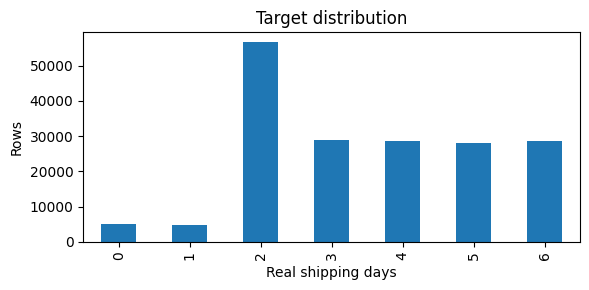

In [5]:
print("Real shipping days (% of rows):")
print(raw[TARGET].value_counts(normalize=True).sort_index().mul(100).round(1))
print(f"\nMean {raw[TARGET].mean():.2f} | median {raw[TARGET].median():.0f} | std {raw[TARGET].std():.2f}")

fig, ax = plt.subplots(figsize=(6, 3))
raw[TARGET].value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("Real shipping days"); ax.set_ylabel("Rows"); ax.set_title("Target distribution")
plt.tight_layout(); plt.show()

## Step 3 – Prove the leakage
The model is used **when the order is placed**. Any column calculated from the real shipping days, or recorded after shipping,
would give the answer away. Each cell below shows the evidence before the column is dropped.

### 3.1 `Late_delivery_risk` is calculated from the target

In [6]:
rule = (raw[TARGET] > raw[SCHED]).astype(int)
match_pct = (rule == raw[LATE]).mean() * 100
print(f"{LATE} == (real days > scheduled days) for {match_pct:.1f}% of rows")
print("\nRows breaking the rule, by Delivery Status:")
print(raw.loc[rule != raw[LATE], "Delivery Status"].value_counts())

Late_delivery_risk == (real days > scheduled days) for 97.5% of rows

Rows breaking the rule, by Delivery Status:
Delivery Status
Shipping canceled    4423
Name: count, dtype: int64


→ The late flag is just "real days > scheduled days", so it leaks the target. The few exceptions are cancelled shipments.

### 3.2 `Delivery Status` is a text version of real vs scheduled days

In [7]:
gap = raw[TARGET] - raw[SCHED]
pd.crosstab(raw["Delivery Status"], np.sign(gap).map({-1: "real < scheduled", 0: "real = scheduled", 1: "real > scheduled"}))

col_0,real < scheduled,real = scheduled,real > scheduled
Delivery Status,,,
Advance shipping,41592,0,0
Late delivery,0,0,98977
Shipping canceled,1774,1557,4423
Shipping on time,0,32196,0


→ "Advance shipping", "Shipping on time" and "Late delivery" each sit in exactly one column: leakage.

### 3.3 Shipping date = order date + real shipping days

In [8]:
order_dt = pd.to_datetime(raw["order date (DateOrders)"], format=DATE_FMT)
ship_dt = pd.to_datetime(raw["shipping date (DateOrders)"], format=DATE_FMT)
gap_days = (ship_dt - order_dt).dt.days
print(f"(shipping date - order date) in whole days == real shipping days for {(gap_days == raw[TARGET]).mean() * 100:.1f}% of rows")

(shipping date - order date) in whole days == real shipping days for 97.4% of rows


→ Knowing the shipping date means knowing the answer (small differences come from Same Day orders shipped a few hours later).

### 3.4 `Order Status` is recorded after fulfilment

In [9]:
pd.crosstab(raw["Order Status"], raw["Delivery Status"])

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Order Status,,,,
CANCELED,0,0,3692,0
CLOSED,4809,11109,0,3698
COMPLETE,14136,34199,0,11156
ON_HOLD,2413,5450,0,1941
PAYMENT_REVIEW,420,1082,0,391
PENDING,4857,11712,0,3658
PENDING_PAYMENT,9588,22922,0,7322
PROCESSING,5369,12503,0,4030
SUSPECTED_FRAUD,0,0,4062,0


→ Statuses like COMPLETE / CLOSED describe how the order ended. We use Order Status once to remove cancelled orders (Step 5), then drop it.

### 3.5 `Days for shipment (scheduled)` – redundant, not leakage
Scheduled days are known at order time, so they do **not** leak. We drop them because Shipping Mode already fixes them:

In [10]:
pd.crosstab(raw["Shipping Mode"], raw[SCHED])

Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0,27814,0,0
Same Day,9737,0,0,0
Second Class,0,0,35216,0
Standard Class,0,0,0,107752


→ One scheduled value per shipping mode. (Common viva trick question: *redundant*, not *leaky*.)

### 3.6 Do the profit columns depend on the target?
If profit changed strongly with real shipping days, it might include shipping costs (calculated after shipping). Flat averages support keeping it.

In [11]:
shipped = raw[~raw["Order Status"].isin(["CANCELED", "SUSPECTED_FRAUD"])]
shipped.groupby(TARGET)[["Benefit per order", "Order Item Profit Ratio"]].mean().round(3)

,Benefit per order,Order Item Profit Ratio
Days for shipping (real),,
0,22.710,0.123
1,18.924,0.111
2,23.292,0.126
3,21.453,0.117
4,22.231,0.123
5,21.186,0.116
6,21.147,0.118


## Step 4 – Order-level structure (why the split must be grouped)
Each row is an **order item**, not an order. If all items of an order share the target and the order details,
a random split would put "sibling" rows in both train and test and the scores would be too optimistic.

In [12]:
per_order = raw.groupby(GROUP).agg(
    items=(TARGET, "size"),
    n_target=(TARGET, "nunique"),
    n_mode=("Shipping Mode", "nunique"),
    n_status=("Order Status", "nunique"),
)
print("Items per order:\n", per_order["items"].describe().round(2), "\n")
print(f"Orders with more than one item: {(per_order['items'] > 1).mean() * 100:.1f}%")
print(f"Orders whose items have different real shipping days: {(per_order['n_target'] > 1).sum()}")
print(f"Orders whose items have different Shipping Mode:      {(per_order['n_mode'] > 1).sum()}")
print(f"Orders whose items have different Order Status:       {(per_order['n_status'] > 1).sum()}")

Items per order:
 count    65752.00
mean         2.75
std          1.48
min          1.00
25%          1.00
50%          3.00
75%          4.00
max          5.00
Name: items, dtype: float64 

Orders with more than one item: 69.8%
Orders whose items have different real shipping days: 0
Orders whose items have different Shipping Mode:      0
Orders whose items have different Order Status:       0


→ If "different real shipping days" is 0, every item of an order has the same answer – the evidence for grouping by Order Id.

## Step 5 – Remove cancelled and suspected-fraud orders
These orders were **never shipped**, yet the data still gives them a "real shipping days" value that does not describe a delivery.
They are removed **per order**, so no order is left half in the data.

In [13]:
EXCLUDE_STATUS = ["CANCELED", "SUSPECTED_FRAUD"]
bad_orders = raw.loc[raw["Order Status"].isin(EXCLUDE_STATUS), GROUP].unique()
excluded = raw[raw[GROUP].isin(bad_orders)]

print(f"Rows removed:   {len(excluded):,}")
print(f"Orders removed: {len(bad_orders):,}")
print("\nDelivery Status of removed rows:\n", excluded["Delivery Status"].value_counts())

df = raw[~raw[GROUP].isin(bad_orders)].copy()
print(f"\nAfter filtering: {df.shape[0]:,} rows, {df[GROUP].nunique():,} orders")

Rows removed:   7,754
Orders removed: 2,855

Delivery Status of removed rows:
 Delivery Status
Shipping canceled    7754
Name: count, dtype: int64

After filtering: 172,765 rows, 62,897 orders


## Step 6 – Drop columns, each with a recorded reason
### 6.1 Find exactly duplicated columns
Instead of assuming duplicates, compare every pair of columns (numbers with a small tolerance, text exactly).

In [14]:
def same_values(a, b):
    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        return np.allclose(a.to_numpy(float), b.to_numpy(float), equal_nan=True)
    return a.astype(str).equals(b.astype(str))

n_unique = df.nunique(dropna=False)
cols = list(df.columns)
dup_pairs = [
    (c1, c2)
    for i, c1 in enumerate(cols) for c2 in cols[i + 1:]
    if n_unique[c1] == n_unique[c2] and same_values(df[c1], df[c2])   # equal n_unique = quick pre-filter
]
for p in dup_pairs:
    print(" = ".join(p))

Benefit per order = Order Profit Per Order
Sales per customer = Order Item Total
Category Id = Product Category Id
Customer Email = Customer Password
Customer Id = Order Customer Id
Order Item Cardprod Id = Product Card Id
Order Item Product Price = Product Price


### 6.2 ID ↔ name pairs
If a code column maps one-to-one to a readable name (e.g. Category Id ↔ Category Name), keeping both is the same feature twice.
We keep the readable name (so the feature **Category Name** is used; Category Id carries identical information).

In [15]:
def one_to_one(a, b):
    return df.groupby(a)[b].nunique().max() == 1 and df.groupby(b)[a].nunique().max() == 1

ID_NAME_PAIRS = [("Category Id", "Category Name"), ("Department Id", "Department Name"), ("Product Card Id", "Product Name")]
id_name_result = {f"{a} <-> {b}": one_to_one(a, b) for a, b in ID_NAME_PAIRS}
id_name_result

{'Category Id <-> Category Name': False,
 'Department Id <-> Department Name': True,
 'Product Card Id <-> Product Name': True}

### 6.3 Build the drop log
Every dropped column gets a plain-English reason. The target and Order Id are **protected** and can never be dropped.

In [16]:
drop_log = []
PROTECTED = {TARGET, GROUP}

def log_drop(columns, reason):
    for c in columns:
        if c in df.columns and c not in PROTECTED and c not in {d["column"] for d in drop_log}:
            drop_log.append({"column": c, "reason": reason})

# 1. Leakage – calculated from the target or recorded after fulfilment
log_drop([LATE], "Leakage: defined as real days > scheduled days")
log_drop(["Delivery Status"], "Leakage: text version of real vs scheduled days")
log_drop(["shipping date (DateOrders)"], "Leakage: order date + real shipping days")
log_drop(["Order Status"], "Leakage: recorded after fulfilment (used only to filter)")
# 2. Redundant – known at order time but fully determined by Shipping Mode
log_drop([SCHED], "Redundant: fully determined by Shipping Mode")
# 3. Personal / masked data
log_drop(["Customer Email", "Customer Password"], "Masked (all 'XXXXXXXXX'), no information")
log_drop(["Customer Fname", "Customer Lname", "Customer Street", "Customer Zipcode"], "Personal data (PII)")
# 4. Empty, mostly missing or constant – detected, not hard-coded
for c in df.columns:
    miss = df[c].isna().mean() * 100
    if miss > 80:
        log_drop([c], f"{miss:.1f}% missing")
    elif df[c].nunique(dropna=True) <= 1:
        log_drop([c], "Constant: a single value in every row")
log_drop(["Product Image"], "Image URL: one per product, duplicates Product Name")
# 5. Exact duplicate columns – keep the clearer name of each pair
KEEP = {"Customer Id", "Product Card Id", "Category Id", "Benefit per order", "Sales per customer", "Product Price"}
for c1, c2 in dup_pairs:
    drop = c2 if c1 in KEEP or c2 not in KEEP else c1
    keep = c1 if drop == c2 else c2
    log_drop([drop], f"Exact duplicate of '{keep}'")
# 6. Code columns that are 1-to-1 with a readable name
for (a, b), ok in zip(ID_NAME_PAIRS, id_name_result.values()):
    if ok:
        log_drop([a], f"1-to-1 with '{b}' (same information as a code)")
# 7. Pure identifiers (Order Id is kept ONLY as the grouping key)
log_drop(["Order Item Id"], "Row identifier")
log_drop(["Customer Id"], "Identifier: would let the model memorise customers")

drop_df = pd.DataFrame(drop_log)
drop_df

,column,reason
0,Late_delivery_risk,Leakage: defined as real days > scheduled days
1,Delivery Status,Leakage: text version of real vs scheduled days
2,shipping date (DateOrders),Leakage: order date + real shipping days
3,Order Status,Leakage: recorded after fulfilment (used only ...
4,Days for shipment (scheduled),Redundant: fully determined by Shipping Mode
5,Customer Email,"Masked (all 'XXXXXXXXX'), no information"
6,Customer Password,"Masked (all 'XXXXXXXXX'), no information"
7,Customer Fname,Personal data (PII)
8,Customer Lname,Personal data (PII)
9,Customer Street,Personal data (PII)


### 6.4 Apply the drops and save the log

In [17]:
df_clean = df.drop(columns=drop_df["column"]).reset_index(drop=True)
drop_df.to_csv(REPORTS_DIR / "drop_log_m1_reg.csv", index=False)
print(f"Dropped {len(drop_df)} columns -> {df_clean.shape[1]} remain")
print(df_clean.columns.tolist())

Dropped 25 columns -> 28 remain
['Type', 'Days for shipping (real)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'Shipping Mode']


## Step 7 – Final quality checks
No duplicate rows and no missing values should remain. (Orders repeat across rows because each row is an *item* – that is not duplication.)

In [18]:
print("Exact duplicate rows:", df_clean.duplicated().sum())
remaining_missing = df_clean.isna().sum()
print("Columns with missing values:", remaining_missing[remaining_missing > 0].to_dict() or "none")
print(f"Clean shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns | mean target {df_clean[TARGET].mean():.2f} days")

Exact duplicate rows: 0
Columns with missing values: none
Clean shape: 172,765 rows x 28 columns | mean target 3.50 days


## Step 8 – One shared train/test split, grouped by Order Id
`StratifiedGroupKFold` keeps every order entirely in one set (**grouped**) and keeps the share of each shipping-day value the same
in both sets (**stratified**). One of its 5 folds becomes the test set (≈20%).

| Alternative | Why rejected |
|---|---|
| random `train_test_split` | items of one order land in both sets → leakage, inflated scores |
| `GroupShuffleSplit` | grouped, but does not balance the target |

**Team rule:** nobody re-splits. Everyone loads these files.

### 8.1 Create the split

In [19]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(df_clean, df_clean[TARGET], groups=df_clean[GROUP]))
train = df_clean.iloc[train_idx].reset_index(drop=True)
test = df_clean.iloc[test_idx].reset_index(drop=True)

def summarise(name, d):
    return {"set": name, "rows": len(d), "orders": d[GROUP].nunique(),
            "share_of_rows_%": round(len(d) / len(df_clean) * 100, 1),
            "mean_days": round(d[TARGET].mean(), 3), "std_days": round(d[TARGET].std(), 3)}

split_summary = pd.DataFrame([summarise("full", df_clean), summarise("train", train), summarise("test", test)])
overlap = set(train[GROUP]) & set(test[GROUP])
print("Order Ids appearing in BOTH train and test:", len(overlap))
assert len(overlap) == 0, "Leak: an order is split across train and test"
split_summary

Order Ids appearing in BOTH train and test: 0


,set,rows,orders,share_of_rows_%,mean_days,std_days
0,full,172765,62897,100.0,3.499,1.623
1,train,138098,50318,79.9,3.500,1.626
2,test,34667,12579,20.1,3.494,1.614


### 8.2 Target distribution in train vs test
The bars should match – quick visual proof that the test set is representative.

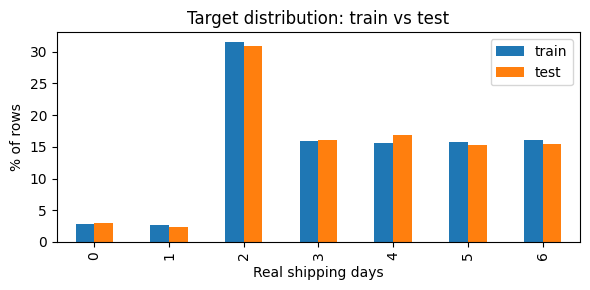

In [20]:
dist = pd.DataFrame({
    "train": train[TARGET].value_counts(normalize=True).sort_index() * 100,
    "test": test[TARGET].value_counts(normalize=True).sort_index() * 100,
})
ax = dist.plot.bar(figsize=(6, 3))
ax.set_xlabel("Real shipping days"); ax.set_ylabel("% of rows"); ax.set_title("Target distribution: train vs test")
plt.tight_layout(); plt.show()

## Step 9 – Save the shared files

In [21]:
train.to_csv(PROCESSED_DIR / "train_reg.csv", index=False)
test.to_csv(PROCESSED_DIR / "test_reg.csv", index=False)

meta = {
    "task": "regression",
    "target": TARGET,
    "group": GROUP,
    "seed": SEED,
    "split": "StratifiedGroupKFold(n_splits=5) on the target, fold 0 = test",
    "excluded_order_status": EXCLUDE_STATUS,
    "dropped_columns": drop_df.to_dict(orient="records"),
    "remaining_columns": df_clean.columns.tolist(),
    "summary": split_summary.to_dict(orient="records"),
}
(PROCESSED_DIR / "split_meta_reg.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved:", "train_reg.csv", "test_reg.csv", "split_meta_reg.json", "reports/drop_log_m1_reg.csv", sep="\n  ")

Saved:
  train_reg.csv
  test_reg.csv
  split_meta_reg.json
  reports/drop_log_m1_reg.csv


## Step 10 – Baselines every model must beat
Two very simple predictors, scored with grouped 5-fold cross-validation on the **training set**:
- **Predict the mean** – the "no model" reference (R² ≈ 0).
- **Predict the mean per Shipping Mode** – a linear model on one-hot shipping mode.

**MAE** = average error in days (easy to explain). **RMSE** punishes big misses more. **R²** = share of variation explained.
If a later model cannot beat the Shipping Mode baseline, it adds nothing beyond "look up the average for that mode".

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

X_train, y_train, g_train = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_train, y_train, g_train))
SCORING = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

baselines = {
    "Predict the mean": DummyRegressor(strategy="mean"),
    "Mean per Shipping Mode": Pipeline([
        ("prep", ColumnTransformer([("mode", OneHotEncoder(handle_unknown="ignore"), ["Shipping Mode"])])),
        ("model", LinearRegression()),
    ]),
}
rows = []
for name, model in baselines.items():
    s = cross_validate(model, X_train, y_train, cv=cv_splits, scoring=SCORING)
    rows.append({"baseline": name, "MAE": -s["test_MAE"].mean(), "RMSE": -s["test_RMSE"].mean(), "R2": s["test_R2"].mean()})
baseline_table = pd.DataFrame(rows).set_index("baseline").round(4)
baseline_table

,MAE,RMSE,R2
baseline,,,
Predict the mean,1.4276,1.6259,-0.0000
Mean per Shipping Mode,0.9867,1.2710,0.3888


## Step 11 – Viva summary
Every number to quote comes from here, not from memory.

In [23]:
tr, te = split_summary.set_index("set").loc["train"], split_summary.set_index("set").loc["test"]
print(f'''
DATASET      DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
TASK         Regression - predict {TARGET} at order placement
RAW          {raw.shape[0]:,} rows x {raw.shape[1]} columns, {raw[GROUP].nunique():,} orders
TARGET       mean {raw[TARGET].mean():.2f} days, range {raw[TARGET].min()}-{raw[TARGET].max()}
LEAKAGE      {LATE}, Delivery Status, shipping date, Order Status
REDUNDANT    {SCHED} (determined by Shipping Mode)
EXCLUDED     {len(excluded):,} rows / {len(bad_orders):,} orders (CANCELED, SUSPECTED_FRAUD)
DROPPED      {len(drop_df)} columns (reports/drop_log_m1_reg.csv)
CLEAN        {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns
TRAIN / TEST {int(tr.rows):,} / {int(te.rows):,} rows, mean {tr.mean_days} / {te.mean_days} days, overlap {len(overlap)} orders
BASELINES    mean MAE {baseline_table.loc["Predict the mean", "MAE"]:.4f} | Shipping Mode MAE {baseline_table.loc["Mean per Shipping Mode", "MAE"]:.4f}
''')


DATASET      DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
TASK         Regression - predict Days for shipping (real) at order placement
RAW          180,519 rows x 53 columns, 65,752 orders
TARGET       mean 3.50 days, range 0-6
LEAKAGE      Late_delivery_risk, Delivery Status, shipping date, Order Status
REDUNDANT    Days for shipment (scheduled) (determined by Shipping Mode)
EXCLUDED     7,754 rows / 2,855 orders (CANCELED, SUSPECTED_FRAUD)
DROPPED      25 columns (reports/drop_log_m1_reg.csv)
CLEAN        172,765 rows x 28 columns
TRAIN / TEST 138,098 / 34,667 rows, mean 3.5 / 3.494 days, overlap 0 orders
BASELINES    mean MAE 1.4276 | Shipping Mode MAE 0.9867



**My contribution in one sentence:** I loaded and cleaned the data, proved and removed the leakage columns,
built the shared train/test split grouped by Order Id, and set the baselines the whole team must beat.